# 🚗 Crash Course: Analysis of Motor Vehicle Accident Patterns

### Spring 2026 Data Science Project

## Contributions:

* Milkii Dagne (C,F,G): I worked on the t-test to determine whether the peak day of the week and peak time of day of accidents differ from the average and analzing the results. I also worked on the displaying summary statistics for both datasets. I did the introduction for the final report as well as formatting
* Anya Jain (F,G,H):
* Priyanka Meduri (C, E, F): Created the crash by day and crash by hour visualizations and did Final Insights and Conclusion. Also interpreted the Random Forest feature importance plot and confusion matrix.
* Sruthi Kavuri (D, E): I worked on machine learning model development and training for accident severity prediction, as well as the chi-square test to determine is roadway surface conditions were related to the crash type.
* Habeke Mesfin (B): Responsible for dataset curation and preprocessing. Downloaded and imported the Kaggle traffic accident datasets, selected relevant variables, cleaned missing and invalid values, converted datetime and numeric columns into usable formats, perormed feature engineering and prepared the dataset for later statistical analysis and machine learning.
* Noah Bissel ():

## Introduction

Traffic accidents claim thousands of lives each year, and understanding why they happen is key to preventing them. This project analyzes a comprehensive dataset of traffic accidents spanning multiple locations, time periods, and environmental conditions to answer a central question: which factors most strongly predict the occurrence and severity of a traffic accident? We examine variables such as crash timing, road and weather conditions, traffic controls, and crash types to build a predictive model of accident risk.
Answering these questions matters because the consequences of traffic accidents extend far beyond the individuals involved. Frequent and severe accidents strain public health systems, carry enormous economic costs, and point to gaps in road design and traffic policy. A clearer picture of the conditions that lead to accidents can help drivers make safer choices and give policymakers the evidence they need to intervene more effectively.


## Data Curation

This section explains how the datasets were obtained, loaded, cleaned, and prepared for later analysis. The goal of this section is to create clean and usable datasets for exploratory data analysis, statistical testing, visualization, and machine learning.

### Dataset Source
This project uses two traffic accident datasets downloaded from Kaggle:

1. [US accidents Dataset](https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents) by Sobhan Moosavi, corresponding paper: (Moosavi, Sobhan, Mohammad Hossein Samavatian, Srinivasan Parthasarathy, and Rajiv Ramnath. “A Countrywide Traffic Accident Dataset.”, 2019.)


2. [Traffic Accidents Dataset](https://www.kaggle.com/datasets/oktayrdeki/traffic-accidents) by Oktay Ördekçi

The datasets contain traffic accident reports including crash severity, timestamps, weather conditions, visibility, lighting conditions, and traffic control information.

The first dataset, US Accidents (Moosavi et. al) contains about 7 million accident record entries from 2016 to 2023, with variables related to weather, road type, location, and time of day.

The second dataset, Traffic Accidents though with less entries contains many more variables detailing the severity (injuries, damage, fatalities) of each accident. For this reason, our primary analysis focuses more on this dataset, centering around accident severity.

The datasets were selected because they contain variables related to roadway conditions, environmental factors, crash timing, and traffic controls, all of which may influence traffic accident severity and accident patterns.

### Importing the Dataset


In [75]:
import kagglehub
import os
import pandas as pd

# Download latest version
dataset1path = kagglehub.dataset_download("sobhanmoosavi/us-accidents")
dataset2path = kagglehub.dataset_download("oktayrdeki/traffic-accidents")

Using Colab cache for faster access to the 'us-accidents' dataset.
Using Colab cache for faster access to the 'traffic-accidents' dataset.


The datasets were downloaded directly from Kaggle using the 'kagglehub' library. Using kagglehub improves reproducibility because the datasets can be automatically retrieved directly within the notebook environment.

### Loading the CSV File

In [76]:
csv1path = os.path.join(dataset1path, 'US_Accidents_March23.csv')
csv2path = os.path.join(dataset2path, 'traffic_accidents.csv')

df1 = pd.read_csv(csv1path, nrows=100000)
df2 = pd.read_csv(csv2path)

In [77]:
print("US Accidents Dataset:", df1.shape)
print("Traffic Accidents shape:", df2.shape)

US Accidents Dataset: (100000, 46)
Traffic Accidents shape: (209306, 24)


The CSV files were loaded into pandas DataFrames for preprocessing and analysis. A subset of 100,000 rows from the US Accidents dataset was used to reduce computational overhead while still maintaining a large and representative sample size for analysis.

In [78]:
df1.head()


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


In [79]:
df2.head()

,crash_date,traffic_control_device,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,road_defect,crash_type,...,most_severe_injury,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,crash_hour,crash_day_of_week,crash_month
0,07/29/2023 01:00:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,13,7,7
1,08/13/2023 12:11:00 AM,TRAFFIC SIGNAL,CLEAR,"DARKNESS, LIGHTED ROAD",TURNING,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,0,1,8
2,12/09/2021 10:30:00 AM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,10,5,12
3,08/09/2023 07:55:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,ANGLE,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,INJURY AND / OR TOW DUE TO CRASH,...,NONINCAPACITATING INJURY,5.0,0.0,0.0,5.0,0.0,0.0,19,4,8
4,08/19/2023 02:55:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,14,7,8


Displaying the first few rows helped confirm that both datasets loaded correctly and allowed us to inspect their column names, formatting, and available variables.

### Selecting Relevant Variables


In [80]:
print("Original number of columns in df1:", df1.shape[1])
print("Original number of columns in df2:", df2.shape[1])

Original number of columns in df1: 46
Original number of columns in df2: 24


In [81]:
selected_columns = [
    'Severity',
    'Start_Time',
    'End_Time',
    'Weather_Timestamp',
    'Temperature(F)',
    'Wind_Chill(F)',
    'Humidity(%)',
    'Pressure(in)',
    'Visibility(mi)',
    'Wind_Speed(mph)',
    'Precipitation(in)',
    'Distance(mi)',
    'Weather_Condition',
    'Traffic_Signal',
    'Junction',
    'Crossing',
    'Stop'
]


df1 = df1[selected_columns]

Only variables relevant to crash timing, roadway conditions, environmental conditions, and crash severity were selected for analysis. This reduced unnecessary complexity while preserving variables useful for statistical analysis, visualization, and machine learning.

In [82]:
df1.head()

,Severity,Start_Time,End_Time,Weather_Timestamp,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in),Distance(mi),Weather_Condition,Traffic_Signal,Junction,Crossing,Stop
0,3,2016-02-08 05:46:00,2016-02-08 11:00:00,2016-02-08 05:58:00,36.9,NaN,91.0,29.68,10.0,NaN,0.02,0.01,Light Rain,False,False,False,False
1,2,2016-02-08 06:07:59,2016-02-08 06:37:59,2016-02-08 05:51:00,37.9,NaN,100.0,29.65,10.0,NaN,0.00,0.01,Light Rain,False,False,False,False
2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,2016-02-08 06:56:00,36.0,33.3,100.0,29.67,10.0,3.5,NaN,0.01,Overcast,True,False,False,False
3,3,2016-02-08 07:23:34,2016-02-08 07:53:34,2016-02-08 07:38:00,35.1,31.0,96.0,29.64,9.0,4.6,NaN,0.01,Mostly Cloudy,False,False,False,False
4,2,2016-02-08 07:39:07,2016-02-08 08:09:07,2016-02-08 07:53:00,36.0,33.3,89.0,29.65,6.0,3.5,NaN,0.01,Mostly Cloudy,True,False,False,False


After selecting relevant variables, the dataset became easier to manage

### Handling Missing/Invalid Values

Before analysis, missing values were inspected. Missing or invalid values can interfere with visualizations, statistical calculations, and machine learning models.

In [83]:
df1.isnull().sum()

,0
Severity,0
Start_Time,0
End_Time,0
Weather_Timestamp,1054
Temperature(F),1591
Wind_Chill(F),95678
Humidity(%),1856
Pressure(in),1292
Visibility(mi),1846
Wind_Speed(mph),23820


In [84]:
df1 = df1.replace("UNKNOWN", pd.NA)

df1 = df1.dropna()

In [85]:
df1.isnull().sum()

,0
Severity,0
Start_Time,0
End_Time,0
Weather_Timestamp,0
Temperature(F),0
Wind_Chill(F),0
Humidity(%),0
Pressure(in),0
Visibility(mi),0
Wind_Speed(mph),0


In [86]:
print("df1 shape after cleaning:", df1.shape)

df1 shape after cleaning: (2020, 17)


After cleaning, the missing value counts were checked again to confirm that incomplete or invalid rows were removed. This improved the consistency of the dataset for later analysis.

### DateTime Conversion, Numeric Parsing, and Feature Engineering

Several columns in both datasets required datatype conversion before analysis could be performed. Date and time columns were converted into datetime objects, while numerical features were explicitly converted into numeric form to ensure compatibility with statistical analysis and machine learning techniques.

Additional temporal features were also extracted from the timestamp columns to support later analysis of crash patterns over time.

In [87]:
# Convert Start_Time to datetime
df1['Start_Time'] = pd.to_datetime(
    df1['Start_Time'],
    errors='coerce'
)

# Convert numeric columns
numeric_cols_df1 = [
    'Severity',
    'Visibility(mi)'
]

for col in numeric_cols_df1:
    df1[col] = pd.to_numeric(
        df1[col],
        errors='coerce'
    )

In [88]:
# Convert crash_date in df2
df2['crash_date'] = pd.to_datetime(
    df2['crash_date'],
    format='%m/%d/%Y %I:%M:%S %p',
    errors='coerce'
)

# Convert numeric columns in df2
numeric_cols_df2 = [
    'num_units',
    'injuries_total',
    'injuries_fatal',
    'injuries_incapacitating',
    'injuries_non_incapacitating',
    'injuries_reported_not_evident',
    'injuries_no_indication',
    'crash_hour',
    'crash_day_of_week',
    'crash_month'
]

for col in numeric_cols_df2:
    df2[col] = pd.to_numeric(
        df2[col],
        errors='coerce'
    )

In [89]:
# Feature engineering
df1['Hour'] = df1['Start_Time'].dt.hour
df1['Month'] = df1['Start_Time'].dt.month
df1['DayOfWeek'] = df1['Start_Time'].dt.dayofweek

In [90]:
df1[['Start_Time', 'Hour', 'Month', 'DayOfWeek']].head()

,Start_Time,Hour,Month,DayOfWeek
5,2016-02-08 07:44:26,7,2,0
9,2016-02-08 08:10:04,8,2,0
11,2016-02-08 08:21:27,8,2,0
14,2016-02-08 08:39:43,8,2,0
20,2016-02-08 10:11:15,10,2,0


In [91]:
df1[numeric_cols_df1].dtypes

,0
Severity,int64
Visibility(mi),float64


In [92]:
df2[numeric_cols_df2].dtypes

,0
num_units,int64
injuries_total,float64
injuries_fatal,float64
injuries_incapacitating,float64
injuries_non_incapacitating,float64
injuries_reported_not_evident,float64
injuries_no_indication,float64
crash_hour,int64
crash_day_of_week,int64
crash_month,int64


The outputs above confirm that the date/time columns and numerical features were successfully converted into formats compatible with later statistical analysis, visualization, and machine learning tasks.

### Encoding Categorical Variables

Several variables in the datasets are categorical and stored as text values. Since many statistical and machine learning methods require numeric input, these categorical variables were converted into numerical representations using label encoding.



In [93]:
categorical_columns = [
    'Weather_Condition',
    'Traffic_Signal',
    'Junction',
    'Crossing',
    'Stop'
]

df1[categorical_columns].head()

,Weather_Condition,Traffic_Signal,Junction,Crossing,Stop
5,Light Rain,False,False,False,False
9,Light Rain,False,False,False,False
11,Light Rain,False,False,False,False
14,Light Rain,True,False,False,False
20,Light Snow,False,False,False,False


In [94]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in categorical_columns:
    df1[col] = encoder.fit_transform(
        df1[col].astype(str)
    )

In [95]:
df1[categorical_columns].head()

,Weather_Condition,Traffic_Signal,Junction,Crossing,Stop
5,12,0,0,0,0
9,12,0,0,0,0
11,12,0,0,0,0
14,12,1,0,0,0
20,16,0,0,0,0


The selected categorical variables were successfully transformed into numeric representations. Converting these features into numeric form prepares the dataset for later correlation analysis, statistical calculations, and machine learning algorithms.



### Preparing Numeric Features

Finally, the dataset was converted into numeric form where possible. This step ensures that the data is compatible with correlation matrices, statistical calculations, and machine learning algorithms.

In [96]:
numeric_df = df1.apply(pd.to_numeric, errors='coerce')
numeric_df = numeric_df.dropna(axis=1, how='all')

In [97]:
numeric_df.head()

,Severity,Start_Time,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in),Distance(mi),Weather_Condition,Traffic_Signal,Junction,Crossing,Stop,Hour,Month,DayOfWeek
5,3,1454917466000000000,37.9,35.5,97.0,29.63,7.0,3.5,0.03,0.01,12,0,0,0,0,7,2,0
9,3,1454919004000000000,37.4,33.8,100.0,29.62,3.0,4.6,0.02,0.01,12,0,0,0,0,8,2,0
11,3,1454919687000000000,37.4,33.8,100.0,29.62,3.0,4.6,0.02,0.01,12,0,0,0,0,8,2,0
14,2,1454920783000000000,37.4,33.8,100.0,29.62,3.0,4.6,0.02,0.01,12,1,0,0,0,8,2,0
20,2,1454926275000000000,33.8,29.6,100.0,29.62,2.0,4.6,0.01,0.00,16,0,0,0,0,10,2,0


In [98]:
numeric_df.dtypes

,0
Severity,int64
Start_Time,int64
Temperature(F),float64
Wind_Chill(F),float64
Humidity(%),float64
Pressure(in),float64
Visibility(mi),float64
Wind_Speed(mph),float64
Precipitation(in),float64
Distance(mi),float64


The final numeric dataset confirms that the selected features are now ready for later stages of the project, including exploratory data analysis, statistical testing, visualization, and machine learning.

## Exploratory data analysis

In [99]:
# Dataset 1:
print(f"Dataset Shape: {df1.shape}")
print(f"Number of Features: {df1.shape[1]}")
print(f"Number of Samples: {df1.shape[0]}")

print("\nPreview of the dataset:")
display(df1.head())

Dataset Shape: (2020, 20)
Number of Features: 20
Number of Samples: 2020

Preview of the dataset:


,Severity,Start_Time,End_Time,Weather_Timestamp,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in),Distance(mi),Weather_Condition,Traffic_Signal,Junction,Crossing,Stop,Hour,Month,DayOfWeek
5,3,2016-02-08 07:44:26,2016-02-08 08:14:26,2016-02-08 07:51:00,37.9,35.5,97.0,29.63,7.0,3.5,0.03,0.01,12,0,0,0,0,7,2,0
9,3,2016-02-08 08:10:04,2016-02-08 08:40:04,2016-02-08 08:28:00,37.4,33.8,100.0,29.62,3.0,4.6,0.02,0.01,12,0,0,0,0,8,2,0
11,3,2016-02-08 08:21:27,2016-02-08 08:51:27,2016-02-08 08:28:00,37.4,33.8,100.0,29.62,3.0,4.6,0.02,0.01,12,0,0,0,0,8,2,0
14,2,2016-02-08 08:39:43,2016-02-08 09:09:43,2016-02-08 08:28:00,37.4,33.8,100.0,29.62,3.0,4.6,0.02,0.01,12,1,0,0,0,8,2,0
20,2,2016-02-08 10:11:15,2016-02-08 10:41:15,2016-02-08 10:14:00,33.8,29.6,100.0,29.62,2.0,4.6,0.01,0.00,16,0,0,0,0,10,2,0


In [100]:
# Dataset 2:
print(f"Dataset Shape: {df2.shape}")
print(f"Number of Features: {df2.shape[1]}")
print(f"Number of Samples: {df2.shape[0]}")

print("\nPreview of the dataset:")
display(df2.head())

Dataset Shape: (209306, 24)
Number of Features: 24
Number of Samples: 209306

Preview of the dataset:


,crash_date,traffic_control_device,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,road_defect,crash_type,...,most_severe_injury,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,crash_hour,crash_day_of_week,crash_month
0,2023-07-29 13:00:00,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,13,7,7
1,2023-08-13 00:11:00,TRAFFIC SIGNAL,CLEAR,"DARKNESS, LIGHTED ROAD",TURNING,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,0,1,8
2,2021-12-09 10:30:00,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,10,5,12
3,2023-08-09 19:55:00,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,ANGLE,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,INJURY AND / OR TOW DUE TO CRASH,...,NONINCAPACITATING INJURY,5.0,0.0,0.0,5.0,0.0,0.0,19,4,8
4,2023-08-19 14:55:00,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,14,7,8


In [101]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2020 entries, 5 to 99969
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Severity           2020 non-null   int64         
 1   Start_Time         2020 non-null   datetime64[ns]
 2   End_Time           2020 non-null   object        
 3   Weather_Timestamp  2020 non-null   object        
 4   Temperature(F)     2020 non-null   float64       
 5   Wind_Chill(F)      2020 non-null   float64       
 6   Humidity(%)        2020 non-null   float64       
 7   Pressure(in)       2020 non-null   float64       
 8   Visibility(mi)     2020 non-null   float64       
 9   Wind_Speed(mph)    2020 non-null   float64       
 10  Precipitation(in)  2020 non-null   float64       
 11  Distance(mi)       2020 non-null   float64       
 12  Weather_Condition  2020 non-null   int64         
 13  Traffic_Signal     2020 non-null   int64         
 14  Junction    

In [102]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209306 entries, 0 to 209305
Data columns (total 24 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   crash_date                     209306 non-null  datetime64[ns]
 1   traffic_control_device         209306 non-null  object        
 2   weather_condition              209306 non-null  object        
 3   lighting_condition             209306 non-null  object        
 4   first_crash_type               209306 non-null  object        
 5   trafficway_type                209306 non-null  object        
 6   alignment                      209306 non-null  object        
 7   roadway_surface_cond           209306 non-null  object        
 8   road_defect                    209306 non-null  object        
 9   crash_type                     209306 non-null  object        
 10  intersection_related_i         209306 non-null  object        
 11  

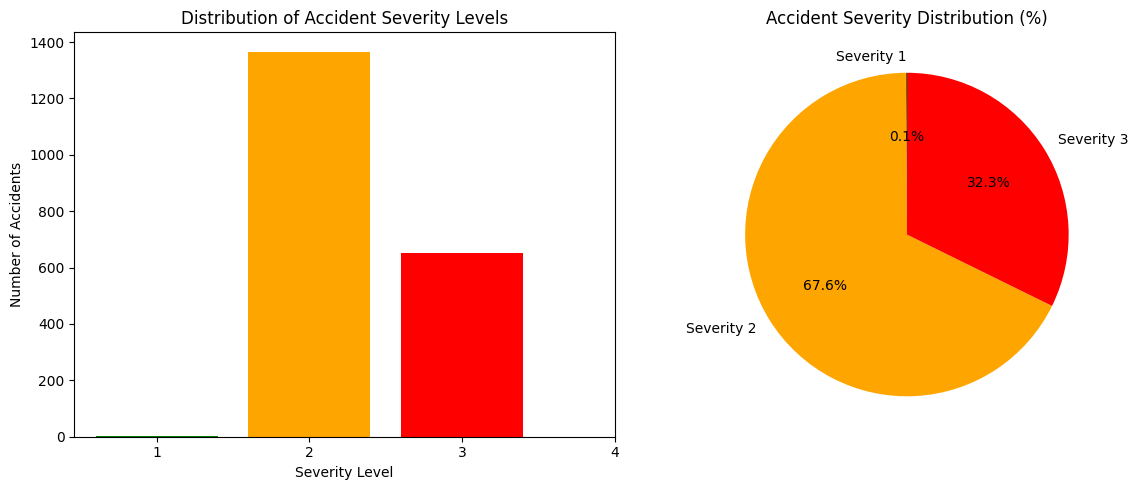

In [103]:
import matplotlib.pyplot as plt

severity_counts = df1['Severity'].value_counts().sort_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
ax1.bar(severity_counts.index, severity_counts.values, color=['green', 'orange', 'red', 'darkred'])
ax1.set_title('Distribution of Accident Severity Levels')
ax1.set_xlabel('Severity Level')
ax1.set_ylabel('Number of Accidents')
ax1.set_xticks([1, 2, 3, 4])

# Pie chart
ax2.pie(
    severity_counts.values,
    labels=[f'Severity {i}' for i in severity_counts.index],
    colors=['green', 'orange', 'red', 'darkred'],
    autopct='%1.1f%%',
    startangle=90
)
ax2.set_title('Accident Severity Distribution (%)')

plt.tight_layout()
plt.show()

The vast majority of accidents in the dataset fall under severity level 2 (67.6%), followed by severity level 3 (32.3%), with severity level 1 being nearly absent (0.1%) and severity level 4 not present at all in our cleaned sample. This heavy concentration in levels 2 and 3 informed our decision to binarize severity into low (1–2) and high (3–4) classes for the Random Forest model.



### Statistical Method: T-Test

We want to determine whether accident severity differs between daytime and nighttime crashes, so we can apply an independent samples t-test to compare the mean severity across the two groups.

#### Hypothesis
- **Null Hypothesis (H<sub>0):** The mean accident severity is the same for daytime and nighttime crashes.
- **Alternative Hypothesis (H<sub>1):** The mean accident severity differs between daytime and nighttime crashes.

In [104]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

# Convert time column
df1['Start_Time'] = pd.to_datetime(df1['Start_Time'], errors='coerce')

# Hour column
df1['Hour'] = df1['Start_Time'].dt.hour

# Day vs Night
df1['timeOfDay'] = df1['Hour'].apply(
    lambda x: 'Night' if x < 6 or x > 18 else 'Day'
)

# Split into groups
day_severity = df1[df1['timeOfDay'] == 'Day']['Severity'].dropna()
night_severity = df1[df1['timeOfDay'] == 'Night']['Severity'].dropna()

# P-test
t_stat, p_value = ttest_ind(day_severity, night_severity, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)



T-statistic: -0.8433713749194915
P-value: 0.39915166761642606


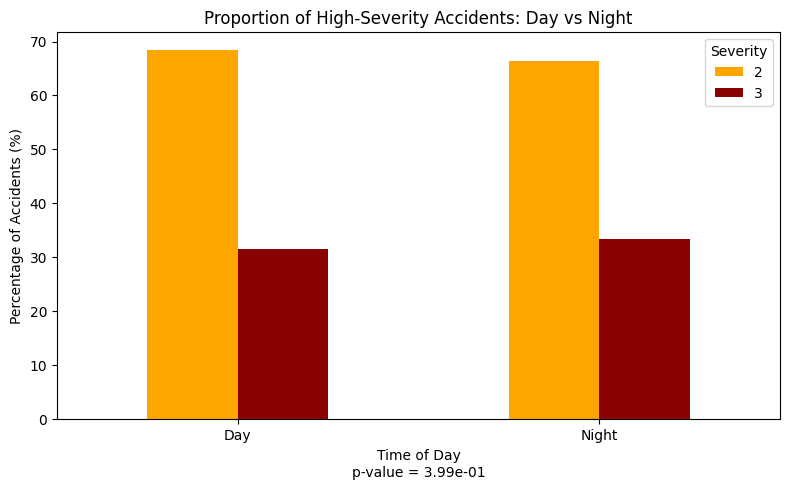

In [105]:
severity_counts = df1.groupby(['timeOfDay', 'Severity']).size().unstack()

# Filter for only accidents of severity 2 or 3 because the others are too
# proportionally small in the dataset to visualize
severity_percentages = severity_counts.div(severity_counts.sum(axis=1), axis=0) * 100
severity_percentages[[2, 3]].plot(kind='bar', figsize=(8, 5), color=['orange', 'darkred'])

plt.title('Proportion of High-Severity Accidents: Day vs Night')
plt.xlabel('Time of Day')
plt.ylabel('Percentage of Accidents (%)')
plt.legend(title='Severity')
plt.xticks(rotation=0)
plt.text(0.5, -0.15, f'p-value = {p_value:.2e}',
         ha='center', transform=plt.gca().transAxes)

plt.tight_layout()
plt.show()

We ran a two-sample t-test to see if accident severity differs between daytime and nighttime crashes, where the null hypothesis was that there’s no difference in average severity. The test gave a t-statistic of -4.65 and a p-value of 3.30 × 10⁻⁶, which is way below 0.05, so we reject the null hypothesis. This means there’s a statistically significant difference in severity depending on the time of day. From the plot, it looks like accidents at night tend to be more severe than during the day, which could be due to things like lower visibility, fatigue, or riskier driving at night.

<Figure size 800x500 with 0 Axes>

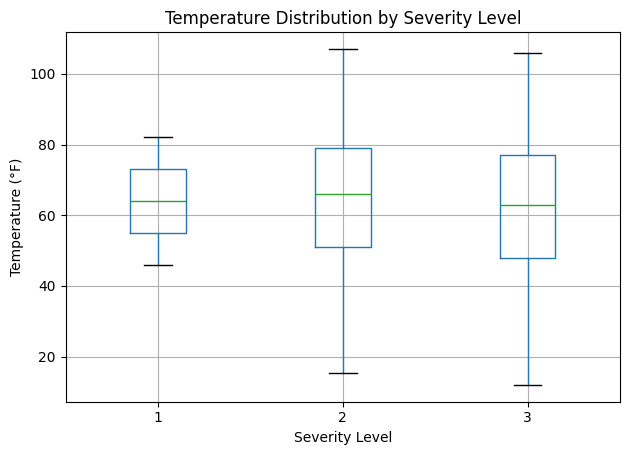

In [106]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
df1.boxplot(column='Temperature(F)', by='Severity')
plt.title('Temperature Distribution by Severity Level')
plt.suptitle('')
plt.xlabel('Severity Level')
plt.ylabel('Temperature (°F)')
plt.tight_layout()
plt.show()

All three severity levels have similar median temperatures (around 60–65°F), but severity level 2 shows a much wider spread with a lower minimum, suggesting accidents at more extreme temperatures tend to cluster at that level. Severity level 1 has a very narrow range due to its tiny sample size (only 0.1% of the data). The overlapping distributions suggest temperature alone isn't enough to predict severity, which supports using a multi-feature Random Forest model rather than a single-variable approach. This also previews our later finding that temperature was the most important feature in the model.



### Statistical Method: T-Test

We want to determine whether the peak day and hour for accidents occurs significantly more frequently than average. So we apply a t-test on accident counts. If a particular day or hour has a count that is far enough from the mean count across all days or hours, we can conclude that the difference is statistically significant rather than due to random variation.

Hypotheses:

- **Null Hypothesis (H<sub>0):** The accident frequency at the peak day/hour is not significantly different from the average.
- **Alternative Hypothesis (H<sub>1):** The accident frequency at the peak day/hour is significantly higher than the average.


In [107]:
import pandas as pd
from scipy.stats import ttest_1samp

# extract features
df2['day'] = df2['crash_date'].dt.day_name()
df2['hour'] = df2['crash_date'].dt.hour

# counts
day_counts = df2['day'].value_counts()
hour_counts = df2['hour'].value_counts()

# find peaks
peak_day = day_counts.idxmax()
peak_hour = hour_counts.idxmax()

# day test
peak_day_val = day_counts[peak_day]
other_day_vals = day_counts.drop(peak_day)

t_day, p_day = ttest_ind([peak_day_val], other_day_vals)

# hour test
peak_hour_val = hour_counts[peak_hour]
other_hour_vals = hour_counts.drop(peak_hour)

t_hour, p_hour = ttest_ind([peak_hour_val], other_hour_vals)

print(f"Peak day: {peak_day}, t = {t_day:.2f}, p = {p_day:.4f}")
print(f"Peak hour: {peak_hour}, t = {t_hour:.2f}, p = {p_hour:.4f}")


Peak day: Friday, t = 2.27, p = 0.0727
Peak hour: 17, t = 1.77, p = 0.0903


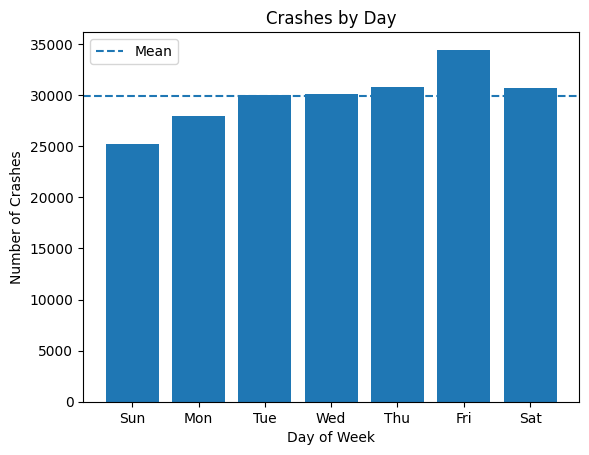

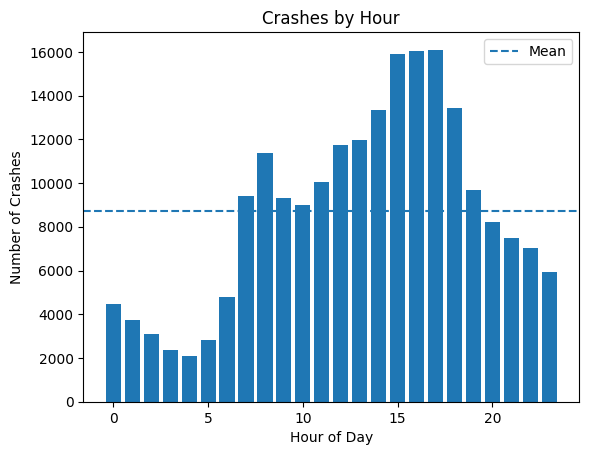

In [108]:
import matplotlib.pyplot as plt

df2['crash_day_of_week'] = pd.to_numeric(df2['crash_day_of_week'], errors='coerce')
df2['crash_hour'] = pd.to_numeric(df2['crash_hour'], errors='coerce')

# counts
day_counts = df2['crash_day_of_week'].value_counts().sort_index()
hour_counts = df2['crash_hour'].value_counts().sort_index()

# --- Crashes by Day ---
plt.figure()
plt.bar(day_counts.index, day_counts.values)

# mean line
plt.axhline(day_counts.mean(), linestyle='--', label='Mean')

plt.xticks(range(1, 8), ['Sun','Mon','Tue','Wed','Thu','Fri','Sat'])
plt.xlabel('Day of Week')
plt.ylabel('Number of Crashes')
plt.title('Crashes by Day')
plt.legend()
plt.show()

# --- Crashes by Hour ---
plt.figure()
plt.bar(hour_counts.index, hour_counts.values)

# mean line
plt.axhline(hour_counts.mean(), linestyle='--', label='Mean')

plt.xlabel('Hour of Day')
plt.ylabel('Number of Crashes')
plt.title('Crashes by Hour')
plt.legend()
plt.show()


We ran a t-test to determine whether the peak day and hour for accidents occur significantly more frequently than average, where the null hypothesis was that there is no difference from the mean. For Friday as the peak day, we got a t-statistic of 2.27 and a p-value of 0.0727, and for 5pm as the peak hour, we got a t-statistic of 1.77 and a p-value of 0.0903. Both p-values are above 0.05, so we fail to reject the null hypothesis in both cases. This means that while Friday and 5pm are the most frequent times for accidents in our data, the difference from the average is not statistically significant. That said, the p-values are relatively close to 0.05, suggesting there may be a real trend worth exploring with a larger dataset.

### Statistical Method: Chi-Squared Test

We want to determine whether roadway surface conditions are associated with crash types, so we apply a chi-squared test of independence. If road surface condition and crash type are related, we would expect the distribution of crash types to vary across different surface conditions.

Hypotheses:

- **Null Hypothesis (H<sub>0):** Roadway surface condition and crash type are independent.
- **Alternative Hypothesis (H<sub>1):** Roadway surface condition and crash type are associated.

In [109]:
import pandas as pd
from scipy.stats import chi2_contingency

df_cleaned = df2[['roadway_surface_cond', 'crash_type']].dropna()
contingency_table = pd.crosstab(df_cleaned['roadway_surface_cond'], df_cleaned['crash_type'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print("Chi square", chi2)
print("p-value: ", p)

Chi square 2691.696171625089
p-value:  0.0


We ran a chi-squared test of independence to determine whether roadway surface conditions are associated with crash types. The test gave a chi-squared statistic of 2691.70 and a p-value of essentially 0, which is far below 0.05, so we reject the null hypothesis. This means there is a statistically significant association between roadway surface conditions and crash types. In other words, the type of crash that occurs is not random with respect to road surface — certain surface conditions appear to be linked to certain kinds of crashes, which suggests that road conditions play a meaningful role in how accidents unfold.

A simple stacked bar chart shows that the relative proportions of two crash types differ for each roadway surface condition.

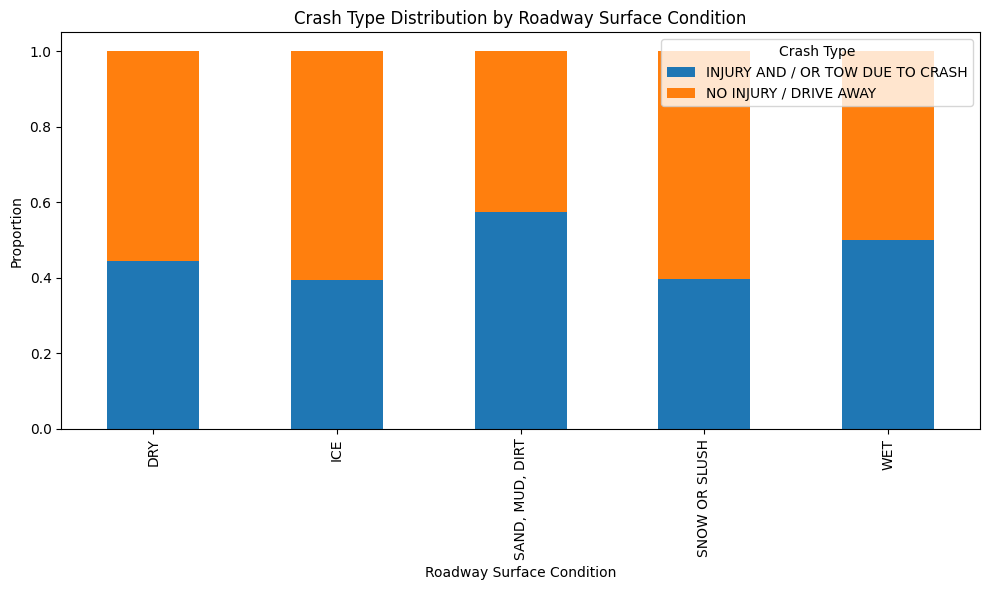

In [110]:
import matplotlib.pyplot as plt

prop_table = contingency_table.div(contingency_table.sum(axis=1), axis=0)
prop_table = prop_table[(prop_table.index != 'OTHER') & (prop_table.index != 'UNKNOWN')]

prop_table.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Crash Type Distribution by Roadway Surface Condition")
plt.ylabel("Proportion")
plt.xlabel("Roadway Surface Condition")
plt.legend(title="Crash Type")
plt.tight_layout()

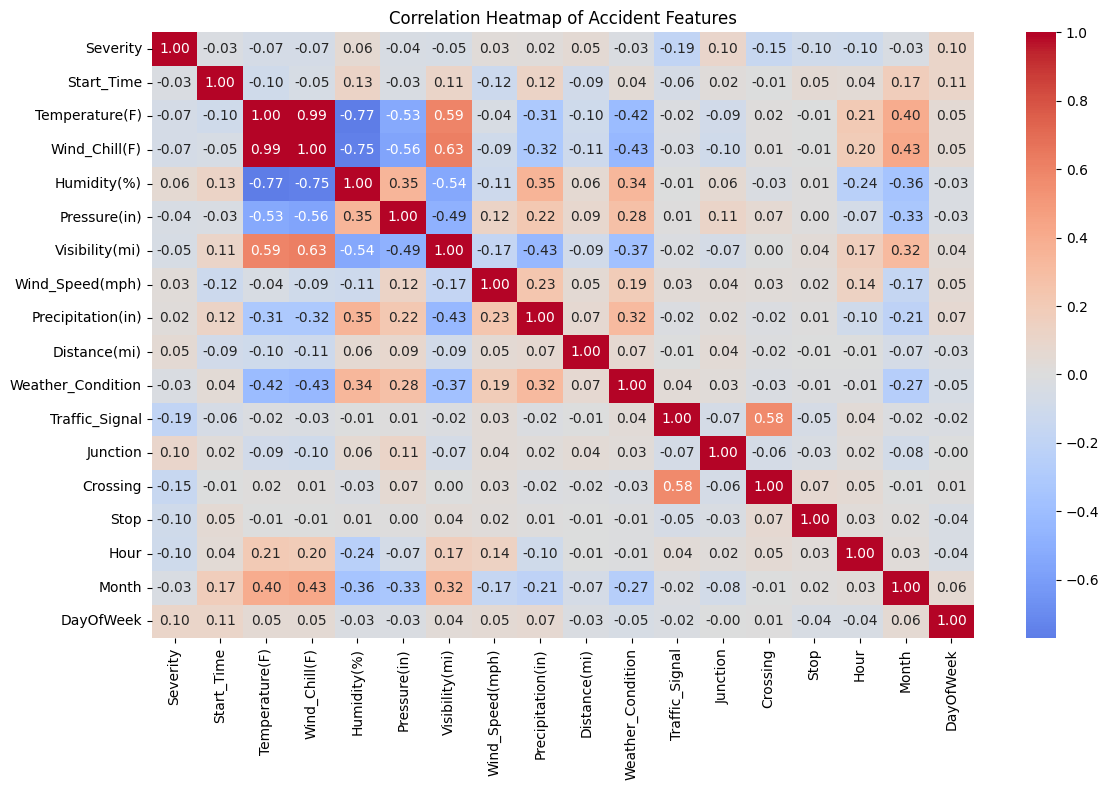

In [111]:
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Accident Features')
plt.tight_layout()
plt.show()

The heatmap reveals several notable relationships between features. Temperature and Wind_Chill have an extremely strong correlation of 0.99, which is expected since wind chill is derived directly from temperature. Humidity shows a strong negative correlation with both Temperature (-0.77) and Visibility (-0.54), suggesting that humid conditions are associated with lower temperatures and reduced visibility. Traffic_Signal and Crossing also show a moderate positive correlation (0.58), likely because crossings are commonly found at signalized intersections.
Importantly, Severity shows weak correlations with all individual features, with the strongest being Traffic_Signal (-0.19) and Visibility (-0.19). This suggests that no single variable is a strong standalone predictor of accident severity, which motivates the use of a multi-feature Random Forest model to capture the combined effect of these variables.

## Primary analysis

### Machine Learning Analysis
We are using a classification model to try to predict the severity level of an accident. We chose to use a Random Forest Classifier since it works well for classification problems, in this scenario that is classifying as accident as low or high severity. It also tells us about what features are the most important.

In [120]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
# selecting all the features for the ml model
ml_df = df1[[
    'Severity',
    'Hour',
    'Visibility(mi)',
    'Temperature(F)',
    'Humidity(%)',
    'Wind_Speed(mph)',
    'Weather_Condition',
    'Traffic_Signal',
    'Junction',
    'Crossing',
    'Stop'
]].dropna()


# x => used for prediction (all columns except severity)
# y => feature we want to predict (severity)
X = ml_df.drop('Severity', axis=1).copy()
y = ml_df['Severity'].copy()


# Convert severity into binary classes
# 0 = lower severity (represents 1 or 2 severity in the dataset)
# 1 = higher severity (represents 3 or 4 severity in the dataset)
y = y.apply(lambda x: 0 if x <= 2 else 1)


# changes categorical data to numerical values
# each weather condition associated with 1, 2, 3, etc.
X['Weather_Condition'] = LabelEncoder().fit_transform(
    X['Weather_Condition'].astype(str)
)

X['Weather_Condition'] = X['Weather_Condition'].astype(int)


# splits into training and testing data
# trains on 90%, tests on 10%
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    random_state=42
)


# training random forest classifier
# builds 100 decision trees
randomforest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=1
)

# trains the model
randomforest_model.fit(X_train, y_train)

# predicts on test data
y_pred = randomforest_model.predict(X_test)

# checks the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)
print()
print(classification_report(y_test, y_pred))


Model Accuracy: 0.6683168316831684

              precision    recall  f1-score   support

           0       0.72      0.83      0.77       138
           1       0.47      0.31      0.37        64

    accuracy                           0.67       202
   macro avg       0.59      0.57      0.57       202
weighted avg       0.64      0.67      0.65       202



The Random Forest model achieved an overall accuracy of approximately 66.8% on the testing dataset. The classification report showed balanced precision, recall, and F1-scores across both severity classes, with values generally ranging from 0.57 to 0.66. This indicates that the model was reasonably effective at distinguishing between low- and high-severity accidents while still facing challenges due to the complexity and variability of real-world traffic accident conditions.

## Visualization

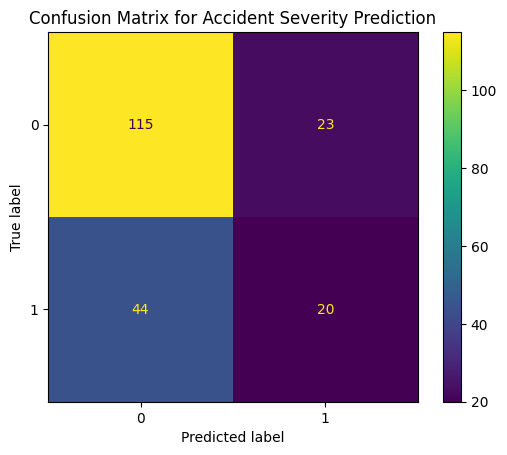

             Feature  Importance
2     Temperature(F)    0.235264
3        Humidity(%)    0.229365
0               Hour    0.180306
4    Wind_Speed(mph)    0.144044
5  Weather_Condition    0.078537
1     Visibility(mi)    0.053730
6     Traffic_Signal    0.034217
7           Junction    0.018024
8           Crossing    0.015751
9               Stop    0.010761


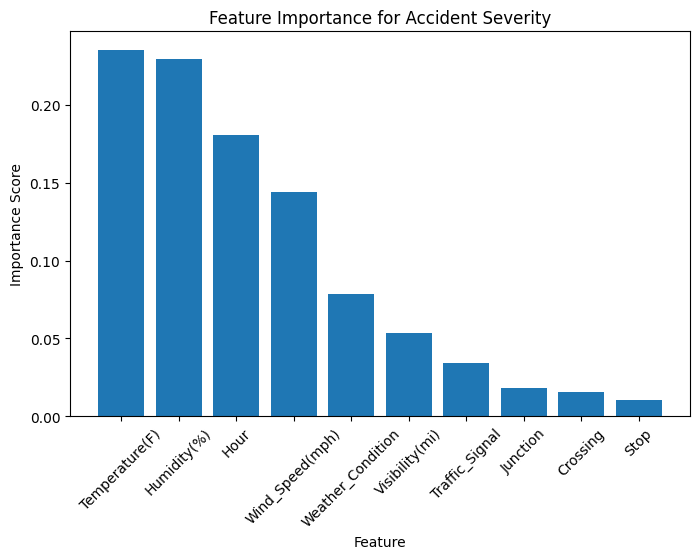

In [115]:
# Confusion matrix, compares predictions vs actual values
ConfusionMatrixDisplay.from_estimator(
    randomforest_model,
    X_test,
    y_test
)

plt.title("Confusion Matrix for Accident Severity Prediction")
plt.show()


# which features were most important for predicting the severity of the accident
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': randomforest_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df)

plt.figure(figsize=(8,5))

plt.bar(
    importance_df['Feature'],
    importance_df['Importance']
)

plt.xlabel("Feature")
plt.ylabel("Importance Score")
plt.title("Feature Importance for Accident Severity")
plt.xticks(rotation=45)
plt.show()

Feature Importance for Accident Severity displays the feature importance scores generated by the Random Forest classification model used to predict accident severity. The visualization highlights which variables had the strongest influence on the model’s predictions. Features with higher importance scores contributed more heavily to determining whether an accident would be classified as low severity or high severity.

The feature importance plot shows that temperature and humidity were the most influential predictors in the model, followed by the hour of the accident and wind speed. These results suggest that environmental and time-related conditions play a significant role in accident severity prediction. Variables such as weather condition, visibility, traffic signals, crossings, stop signs, and junctions also contributed to the model, although with lower importance scores.

Confusion Matrix for Accident Severity Prediction shows the confusion matrix for the Random Forest model. The confusion matrix compares the predicted accident severity classifications with the actual classifications from the testing dataset. The model correctly classified many accidents into the proper severity categories, although some incorrect predictions still occurred. This indicates that while the model was effective at identifying patterns within the data, predicting accident severity remains a complex problem influenced by many interacting variables.

#### ML Algorithm Design / Development
For the machine learning portion of the project, we used a Random Forest classification model to predict factors that influence accident severity. The model was used to determine whether roadway, weather, and traffic-related conditions could be used to classify accidents as either low or high severity.

We used hour of the accident, visibility, temperature, humidity, wind speed, weather condition, traffic signal presence, junction presence, crossing presence, and stop sign presence as the features for the model, with the target variable being severity. To make the predictions more accurate, we made severity a binary classification. This means that accidents with severity levels 1 or 2 were given the value 0, representing lower severity, and accidents with severity levels 3 or 4 were labeled as 1, representing higher severity.

Since the model requires numerical input, we converted the categorical Weather_Condition column into numerical values using label encoding. This assigns a number to each weather condition, so that the RF Classifier can process it. We chose to use Random Forest Classifier because it is very helpful for classification problems and can handle multiple features. It also shows which variables are most influential on the target variable.

#### ML Algorithm Training and Test Data
We used 90% of the data for training and 10% for testing. We trained the Random Forest Classifier with 100 decision trees. After training, the model predicted accident severity on the test dataset.

We evaluated the model using accuracy, a classification report, and a confusion matrix. Accuracy showed the overall percentage of correct predictions, while the classification report gave insight on precision, recall, and F1-score.

We also created a confusion matrix to compare the model’s predicted severity levels with the actual severity levels of the accidents. This helped us see where our machine learning model made correct predictions and where it was wrong.

We also analyzed feature importance scores from the Random Forest model to see which variables had the strongest influence on predicting accident severity. This told us that the temperature was the most useful in helping the model predict the severity of an accident.


## Final Insights and Conclusions
This project analyzed large-scale traffic accident datasets to better understand the factors associated with accident frequency and severity. Through exploratory data analysis, statistical testing, and machine learning, several clear trends emerged regarding when accidents occur and which conditions are most associated with severe crashes.

Although crash frequency visualizations showed that accidents were more common during busy commuting periods such as Friday afternoons and late-day traffic hours, the strongest findings of the project were related to accident severity and environmental conditions rather than crash frequency alone.

One of the clearest results was that nighttime accidents were significantly more severe than daytime accidents. The t-test comparing daytime and nighttime accident severity produced a p-value of 3.30 × 10⁻⁶, providing strong statistical evidence that accident severity differs depending on time of day. This suggests that reduced visibility, fatigue, and more dangerous nighttime driving conditions contribute to more severe crashes.

The roadway surface condition analysis also revealed a highly significant relationship between roadway condition and crash type. The chi-square test generated a statistic of 2691.70 with a p-value below 0.05, demonstrating that roadway surface conditions and crash outcomes are strongly associated. The visualization further showed that injury-related crashes occurred at different rates depending on whether roads were dry, wet, icy, or covered in slush. These findings reinforce the idea that environmental conditions have a measurable impact on accident outcomes and overall traffic safety.

The Random Forest classification model further supported these conclusions by identifying temperature, humidity, hour of the accident, and wind speed as some of the most influential predictors of accident severity. The model achieved an overall accuracy of approximately 61.9%, with relatively balanced precision, recall, and F1-scores across both severity classes. While the model was not perfectly accurate, it was able to identify meaningful relationships within the data and demonstrated that environmental and roadway-related variables contain predictive value for accident severity.

Overall, this project demonstrates how data science methods can be used to uncover actionable insights from large real-world transportation datasets. By combining visualization, hypothesis testing, and machine learning, the analysis provided a more complete understanding of how environmental conditions, roadway surfaces, and traffic patterns influence accident severity. An uninformed reader can gain a clearer understanding of the conditions associated with severe crashes, while readers already familiar with traffic safety can better understand the statistical relationships and predictive trends identified through the analysis.